In [18]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

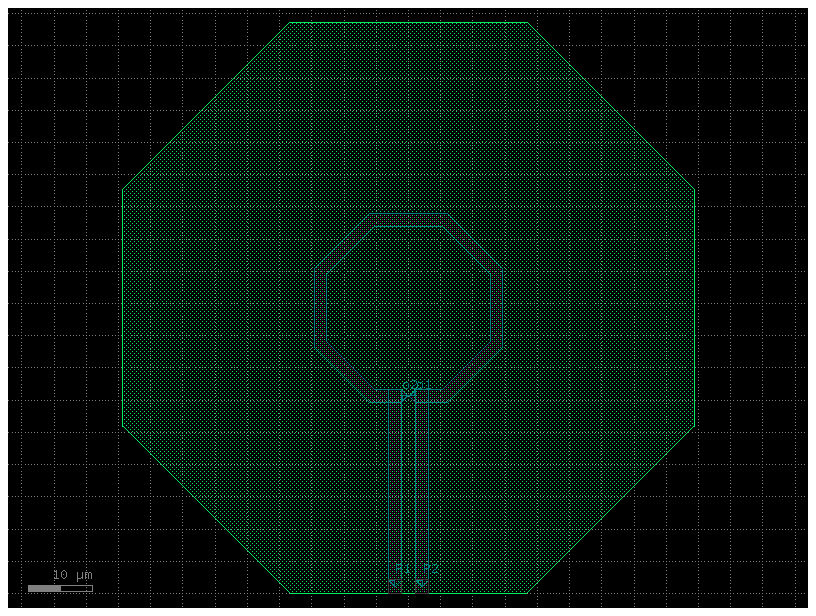

In [19]:
c = gf.components.inductor(
    width=2, 
    space=2.1, 
    diameter=25.35, 
    resistance=0.578, 
    inductance=0.0, 
    turns=1, 
    layer_metal='M3', 
    layer_inductor='M1', 
    layer_metal_pin='WG_PIN', 
    layers_no_fill=('DEVREC', 'NO_TILE_SI')).copy()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()


In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='o1', self.width=2000, trans=r180 *1 1.05,30.685, layer=M3 (49/0), port_type=optical)", "Port(self.name='o2', self.width=2000, trans=r0 *1 -1.05,30.685, layer=M3 (49/0), port_type=optical)", "Port(self.name='P1', self.width=2100, trans=r270 *1 -2.1,2.1, layer=M3 (49/0), port_type=optical)", "Port(self.name='P2', self.width=2100, trans=r270 *1 2.1,2.1, layer=M3 (49/0), port_type=optical)"]

In [21]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-inductor")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=20.0,
)

sim.add_port("o1", layer="metal3")
sim.add_port("o2", layer="metal3")
sim.add_port("P1", from_layer="metal1", to_layer="metal3", geometry="via", excited=True)
sim.add_port("P2", from_layer="metal1", to_layer="metal3", geometry="via", excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [22]:
sim.mesh(preset="graded",margin=0, refined_mesh_size=0.2)

Mesh Summary
Dimensions: 88.7 x 88.7 x 27.6 µm
Nodes:      36,431
Elements:   262,001
Tetrahedra: 193,475
Edge length: 0.10 - 28.79 µm
Quality:    0.611 (min: 0.010)
SICN:       0.669 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (13):
  - metal1_xy [4]
  - metal1_z [5]
  - metal3_xy [6]
  - metal3_z [7]
  - P1 [8]
  - P2 [9]
  - P3 [10]
  - P4 [11]
  - SiO2__None [12]
  - SiO2__passive [13]
  - passive__None [14]
  - air__passive [15]
  - air__None [16]
----------------------------------------
Mesh:   runs/palace-sim-inductor/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:24.471 (5665.340s) [    7892A1FF2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:24.480 (5665.350s) [    7892A1FF2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:24.521 (5665.391s) [    7892A1FF2080]vt

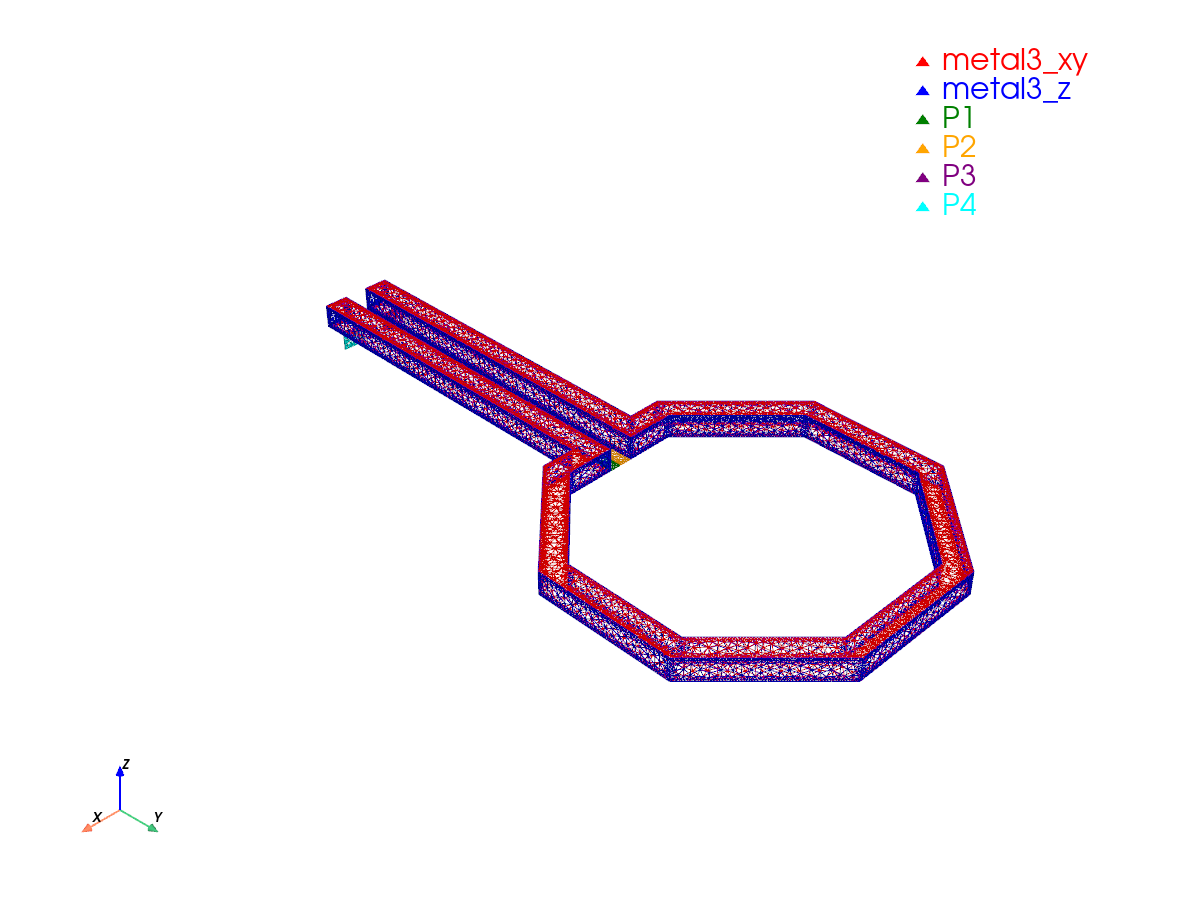

In [23]:
sim.plot_mesh(show_groups=["metal3","P"],interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:25.403 (5666.273s) [    7892A1FF2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:25.412 (5666.282s) [    7892A1FF2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:55:25.473 (5666.343s) [    7892A1FF2080]vt

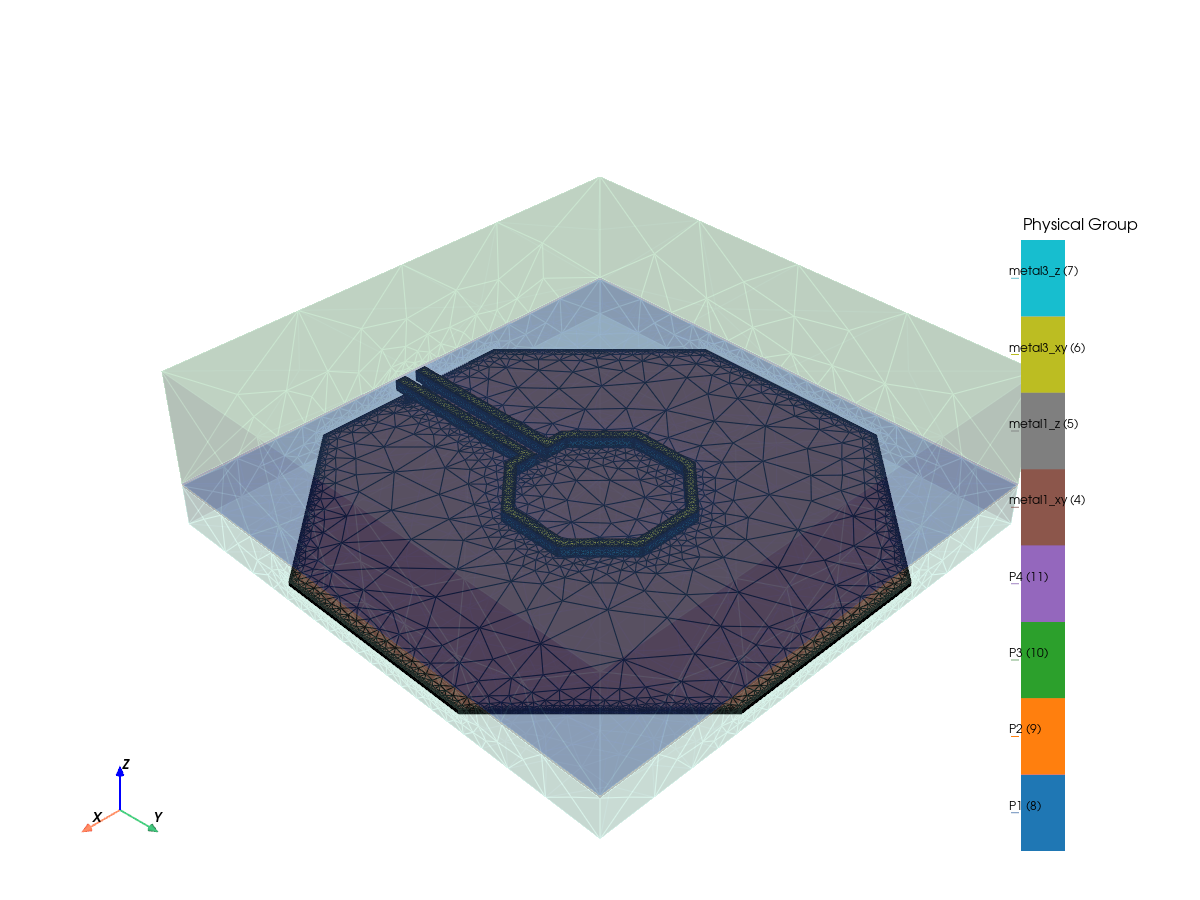

In [24]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [25]:
results = sim.run(parent_dir="runs")

  palace-8e363911  completed  11m 18s
Extracting results.tar.gz...
Downloaded 6 files to runs/sim-data-palace-8e363911


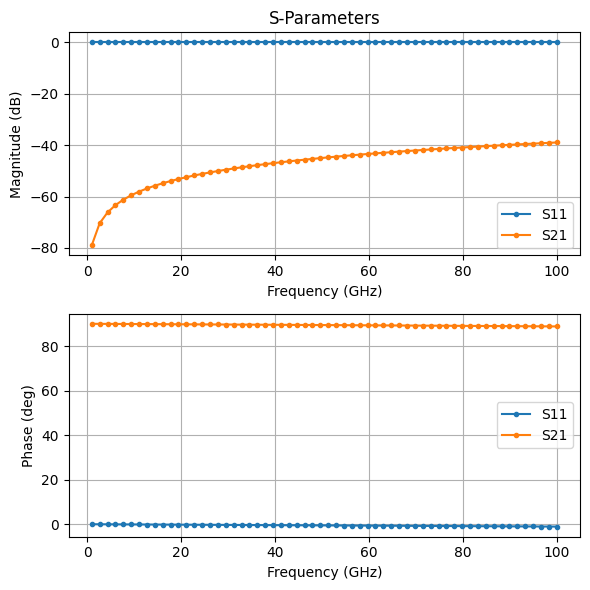

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()